In [1]:
import pandas as pd 

In [2]:
df = pd.read_csv("data/MLINDIV_train_full.csv")
print(df.head())

        dates     times  X  Subject                 eprocs Task_type  \
0  2017-02-07  15:10:46  1        2          Explore-002-1         1   
1  2017-02-07  15:20:22  2        2          Explore-002-2         2   
2  2017-02-07  15:29:23  3        2  Test_Trials_B_1-002-1        B1   
3  2017-02-07  15:29:23  4        2  Test_Trials_B_1-002-1        B1   
4  2017-02-07  15:29:23  5        2  Test_Trials_B_1-002-1        B1   

   Procedure  Sample  objlist  PairList  ...  Nodes.S.L  Nodes.S.M.L  \
0        NaN     NaN      NaN       NaN  ...        NaN          NaN   
1        NaN     NaN      NaN       NaN  ...        NaN          NaN   
2  TrialProc     1.0     20.0       8.0  ...          S            S   
3  TrialProc     2.0     61.0       7.0  ...          S            M   
4  TrialProc     3.0     67.0       1.0  ...          S            M   

   Num.Nodes...Turns..button.presses.  Press.S.L Press.S.M.L fmv_duration  \
0                                 NaN        NaN         

In [18]:
test_df = df[df["eprocs"].str.contains("Test")]
test_df.groupby("StartAt")["accuracy"].mean()


StartAt
A    0.606679
I    0.605119
K    0.602941
L    0.605948
N    0.564338
O    0.539033
P    0.618785
W    0.570093
Y    0.541133
Name: accuracy, dtype: object

In [4]:
test_df.groupby("EndAt")["accuracy"].mean()


EndAt
A    0.533457
I    0.559853
K    0.563536
L    0.571984
N    0.715532
O     0.64432
P    0.492593
W    0.665434
Y         0.5
Name: accuracy, dtype: object

In [19]:
test_df["mean_acc"] = test_df.groupby("Subject")["accuracy"].transform("mean")
test_df['quartile'] = (
    pd.qcut(test_df['mean_acc'], 4, labels=[1, 2, 3, 4])
)

/var/folders/zm/wfc1rvmj47134sp7zlfpr35m0000gn/T/ipykernel_1099/682400664.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_df["mean_acc"] = test_df.groupby("Subject")["accuracy"].transform("mean")
/var/folders/zm/wfc1rvmj47134sp7zlfpr35m0000gn/T/ipykernel_1099/682400664.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_df['quartile'] = (


/var/folders/zm/wfc1rvmj47134sp7zlfpr35m0000gn/T/ipykernel_1099/2095210234.py:12: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  color_dict = {k:v for k, v in zip(new_df["StartAt"].unique(), cm.get_cmap('tab20').colors)}
/var/folders/zm/wfc1rvmj47134sp7zlfpr35m0000gn/T/ipykernel_1099/2095210234.py:23: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  color_dict = {k:v for k, v in zip(new_df["EndAt"].unique(), cm.get_cmap('tab20').colors)}


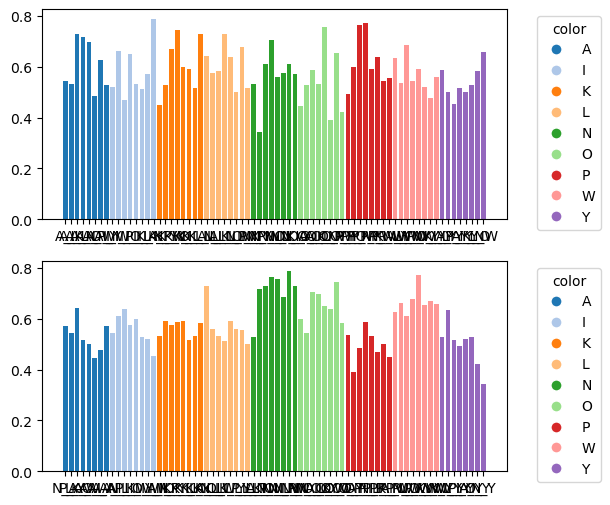

In [5]:
from matplotlib import cm
from matplotlib import pyplot as plt

new_df = test_df.groupby(["StartAt", "EndAt"])["accuracy"].mean()
new_df = new_df.reset_index()
new_df["StartEnd"] = new_df["StartAt"] + "_" + new_df["EndAt"]

fig, (ax, ax2) = plt.subplots(nrows=2, figsize=(6, 6))

# colors = {'A':'tab:blue', 'I':'tab:orange', 'K':'tab:green', 'L':'tab:red', 'N':'tab:purple', 'O':'tab:brown', 'P':'tab:pink', 'W':'tab:o'}
new_df = new_df.sort_values("StartAt")
color_dict = {k:v for k, v in zip(new_df["StartAt"].unique(), cm.get_cmap('tab20').colors)}

new_df["colors"] = new_df["StartAt"].apply(lambda x: color_dict[x])

ax.bar(new_df["StartEnd"], new_df["accuracy"], color=new_df["colors"])

handles = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=v, label=k, markersize=8) for k, v in color_dict.items()]
ax.legend(title='color', handles=handles, bbox_to_anchor=(1.05, 1), loc='upper left')

### COPY PASTE
new_df = new_df.sort_values("EndAt")
color_dict = {k:v for k, v in zip(new_df["EndAt"].unique(), cm.get_cmap('tab20').colors)}

new_df["colors"] = new_df["EndAt"].apply(lambda x: color_dict[x])



ax2.bar(new_df["StartEnd"], new_df["accuracy"], color=new_df["colors"])

handles = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=v, label=k, markersize=8) for k, v in color_dict.items()]
ax2.legend(title='color', handles=handles, bbox_to_anchor=(1.05, 1), loc='upper left')

plt.show()

/var/folders/zm/wfc1rvmj47134sp7zlfpr35m0000gn/T/ipykernel_1099/2067431913.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_df["mean_acc"] = test_df.groupby(["StartAt", "EndAt"])["accuracy"].transform("mean")
/var/folders/zm/wfc1rvmj47134sp7zlfpr35m0000gn/T/ipykernel_1099/2067431913.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_df["StartEnd"] = test_df["StartAt"] + "_" + test_df["EndAt"]
/var/folders/zm/wfc1rvmj47134sp7zlfpr35m0000gn/T/ipykernel_1099/2067431913.py:4: MatplotlibDeprecation

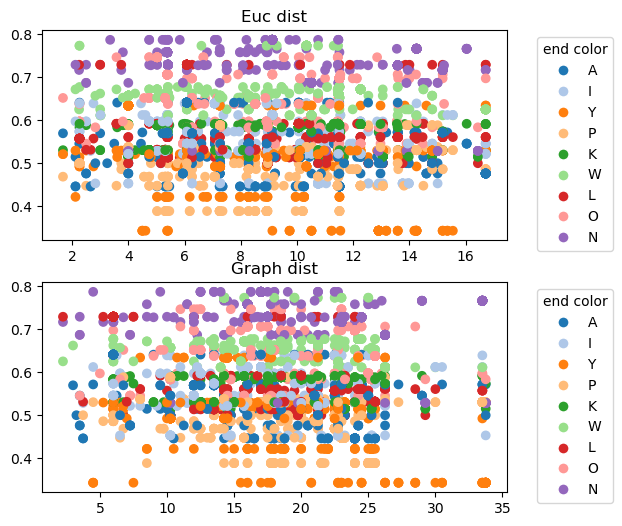

In [28]:
test_df["mean_acc"] = test_df.groupby(["StartAt", "EndAt"])["accuracy"].transform("mean")
test_df["StartEnd"] = test_df["StartAt"] + "_" + test_df["EndAt"]

color_dict = {k:v for k, v in zip(new_df["StartAt"].unique(), cm.get_cmap('tab20').colors)}
test_df["colors"] = test_df["EndAt"].apply(lambda x: color_dict[x])


fig, (ax, ax2) = plt.subplots(nrows=2, figsize=(6, 6))

# colors = {'A':'tab:blue', 'I':'tab:orange', 'K':'tab:green', 'L':'tab:red', 'N':'tab:purple', 'O':'tab:brown', 'P':'tab:pink', 'W':'tab:o'}
new_df = test_df.copy()

ax.scatter(new_df["Euc.Distance"], new_df["mean_acc"], color=new_df["colors"])
ax.set_title("Euc dist")

handles = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=v, label=k, markersize=8) for k, v in color_dict.items()]
ax.legend(title='end color', handles=handles, bbox_to_anchor=(1.05, 1), loc='upper left')

### COPY PASTE
new_df = test_df.copy()

ax2.scatter(new_df["Path.Distance"], new_df["mean_acc"], color=new_df["colors"])
ax2.set_title("Graph dist")
handles = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=v, label=k, markersize=8) for k, v in color_dict.items()]
ax2.legend(title='end color', handles=handles, bbox_to_anchor=(1.05, 1), loc='upper left')

plt.show()

In [6]:
paths = df["paths"]
paths

0       T U U R R Q Q T T X X X X V V X Z P P Z X T T ...
1       E D D D C C I C C B B H H G G L L G A A G G H ...
2                   W U U R J D D D D E F F F E D D J J J
3                                   K J J R U U T X Z P P
4                                 P P Z T T Q H H G G L L
                              ...                        
5082                      Y Y V X Z P P Z T T Q H H G G A
5083                                O M M E E E E F F N N
5084                    N N F F E E M M M S S R R U U W W
5085                O M M E E E E D C C C B B H H H Q T T
5086                                            L L G A A
Name: paths, Length: 5087, dtype: object

In [7]:
paths_with_turns = df["e_paths"]
paths_with_turns

0       U2 U1 R1 R4 Q4 Q3 T3 T4 X4 X3 X2 X3 V2 V1 X1 Z...
1       D4 D3 D4 C4 C3 I2 C1 C4 B4 B3 H3 H4 G4 G3 L2 L...
2       U4 U1 R1 J1 D1 D4 D3 D2 E2 F2 F3 F4 E4 D4 D3 J...
3                           J4 J3 R3 U3 U4 T4 X4 Z1 P2 P2
4                        P3 Z2 T2 T1 Q1 H1 H4 G4 G3 L3 L3
                              ...                        
5082         Y4 V1 X1 Z1 P2 P3 Z2 T2 T1 Q1 H1 H4 G4 G1 A4
5083                        M2 M1 E1 E4 E3 E2 F2 F3 N3 N3
5084      N1 F1 F4 E4 E3 M3 M4 M3 S3 S4 R4 R3 U3 U2 W4 W4
5085    M2 M1 E1 E2 E3 E4 D4 C4 C3 C4 B4 B3 H3 H4 H3 Q...
5086                                          L1 G1 A4 A4
Name: e_paths, Length: 5087, dtype: object

In [8]:
paths_as_ints = paths.apply(lambda x: [ord(char) - 65 for char in x.split()])
paths_as_ints

0       [19, 20, 20, 17, 17, 16, 16, 19, 19, 23, 23, 2...
1       [4, 3, 3, 3, 2, 2, 8, 2, 2, 1, 1, 7, 7, 6, 6, ...
2       [22, 20, 20, 17, 9, 3, 3, 3, 3, 4, 5, 5, 5, 4,...
3              [10, 9, 9, 17, 20, 20, 19, 23, 25, 15, 15]
4            [15, 15, 25, 19, 19, 16, 7, 7, 6, 6, 11, 11]
                              ...                        
5082    [24, 24, 21, 23, 25, 15, 15, 25, 19, 19, 16, 7...
5083               [14, 12, 12, 4, 4, 4, 4, 5, 5, 13, 13]
5084    [13, 13, 5, 5, 4, 4, 12, 12, 12, 18, 18, 17, 1...
5085    [14, 12, 12, 4, 4, 4, 4, 3, 2, 2, 2, 1, 1, 7, ...
5086                                    [11, 11, 6, 0, 0]
Name: paths, Length: 5087, dtype: object

In [9]:
## TODO: Make lists of one paths uniform in length & pad.

In [10]:
import torch
# steal from mathilde
def make_onehot_encoder(label_features):
    """Convert a number to its one-hot representation vector.

    The one-hot representation is also called the 1-of-amount_of_labels.

    Parameters
    ----------
    label_features: int
                    Amount of label categories.

    Returns
    -------
    onehot_encode : function
                    Function that takes in a categorical label integer
                    and outputs its corresponding one-hot.
    """

    def onehot_encode(label):
        y = torch.zeros(label_features)
        if label < label_features:
            y[int(label)] = 1
        return y

    return onehot_encode

In [11]:
onehot_encoder = make_onehot_encoder(26)
onehot_paths = []

for p in paths_as_ints:
    onehot_paths.append([onehot_encoder(pp) for pp in p])
onehot_paths

[[tensor([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
          0., 1., 0., 0., 0., 0., 0., 0.]),
  tensor([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
          0., 0., 1., 0., 0., 0., 0., 0.]),
  tensor([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
          0., 0., 1., 0., 0., 0., 0., 0.]),
  tensor([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1.,
          0., 0., 0., 0., 0., 0., 0., 0.]),
  tensor([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1.,
          0., 0., 0., 0., 0., 0., 0., 0.]),
  tensor([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0.,
          0., 0., 0., 0., 0., 0., 0., 0.]),
  tensor([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0.,
          0., 0., 0., 0., 0., 0., 0., 0.]),
  tensor([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
          0., 1., 0., 0., 0., 0., 0.

In [12]:
print(len(onehot_paths[0]))

178


In [13]:
from models import rnn

# decide on hyperparameters
input_size=26
output_size=26
hidden_dim=32
n_layers=1

# instantiate an RNN
my_rnn = rnn.RNN(input_size, output_size, hidden_dim, n_layers)
print(my_rnn)

RNN(
  (rnn): RNN(26, 32, batch_first=True)
  (fc): Linear(in_features=32, out_features=26, bias=True)
)


In [14]:
from torch import nn

# MSE loss and Adam optimizer with a learning rate of 0.01
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(my_rnn.parameters(), lr=0.01) 

In [15]:
import numpy as np

# train the RNN
def train(rnn, data, print_every):
    
    # initialize the hidden state
    hidden = None      
    
    for i, path in enumerate(data):
        # defining the training data 
        path = np.array(path)
        
        x = path[:-1]
        y = path[1:]
        # print(x)
        # print(y)
        
        # convert data into Tensors
        x_tensor = torch.Tensor(x).unsqueeze(0) # unsqueeze gives a 1, batch_size dimension
        y_tensor = torch.Tensor(y)

        # outputs from the rnn
        prediction, hidden = rnn(x_tensor, hidden)

        ## Representing Memory ##
        # make a new variable for hidden and detach the hidden state from its history
        # this way, we don't backpropagate through the entire history
        hidden = hidden.data

        # calculate the loss
        loss = criterion(prediction, y_tensor)
        # zero gradients
        optimizer.zero_grad()
        # perform backprop and update weights
        loss.backward()
        optimizer.step()

        # display loss and predictions
        if i%print_every == 0:        
            print('Loss: ', loss.item())
            # plt.plot(time_steps[1:], x, 'r.') # input
            # plt.plot(time_steps[1:], prediction.data.numpy().flatten(), 'b.') # predictions
            # plt.show()
    
    return rnn

In [16]:

print_every = 15

trained_rnn = train(my_rnn, onehot_paths, print_every)

Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Loss:  0.057713832706213
Loss:  0.03381907939910889
Loss:  0.028519341722130775
Loss:  0.030927686020731926
Loss:  0.023040059953927994
Loss:  0.019201140850782394
Loss:  0.018338927999138832
Loss:  0.023605255410075188
Loss:  0.023156078532338142
Loss:  0.0243853572756052
Loss:  0.022747546434402466
Loss:  0.019872022792696953


RuntimeError: Expected sequence length to be larger than 0 in RNN